# Приложение D. Добавление новых возможностей в процесс обучения

- В этом приложении мы добавляем несколько более продвинутых функций в функцию обучения, которые используются в типичном предобучении и тонкой настройке
- Следующие три раздела ниже посвящены разогреву скорости обучения, косинусному затуханию и отсечению градиентов
- В последнем разделе эти методы добавляются в функцию обучения

In [ ]:
from importlib.metadata import version
import torch

print("версия torch:", version("torch"))

from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Размер словаря
    "context_length": 256, # Укороченная длина контекста (ориг: 1024)
    "emb_dim": 768,        # Размерность эмбеддинга
    "n_heads": 12,         # Количество голов внимания
    "n_layers": 12,        # Количество слоёв
    "drop_rate": 0.1,      # Коэффициент дропаута
    "qkv_bias": False      # Смещение для query-key-value
}

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Используйте PyTorch 2.9 или новее для стабильных результатов mps
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Устройство:", device)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Отключаем дропаут во время инференса

версия torch: 2.12.0
Устройство: cpu


In [2]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [3]:
from previous_chapters import create_dataloader_v1

# Соотношение обучения/валидации
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

## D.1. Переменная скорость обучения

- При обучении сложных моделей, таких как LLM, применение разогрева скорости обучения может помочь стабилизировать обучение
- При разогреве скорости обучения мы постепенно увеличиваем скорость обучения от очень низкого значения (`initial_lr`) до заданного пользователем максимума (`peak_lr`)
- Таким образом, модель начнёт обучение с малых обновлений весов, что помогает снизить риск больших дестабилизирующих обновлений в процессе обучения

In [4]:
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01

- Обычно количество шагов разогрева составляет от 0,1% до 20% от общего числа шагов
- Мы можем вычислить приращение как разность между `peak_lr` и `initial_lr`, делённую на количество шагов разогрева

In [ ]:
total_steps = len(train_loader) * n_epochs
warmup_steps = int(0.2 * total_steps) # 20% разогрева
print(warmup_steps)

27


 ---

 ## Для чего нужны warmup_steps в обучении llm?

**Warm-up steps (шаги разогрева)** — это постепенное увеличение learning rate от нуля до целевого значения в начале обучения.

**Зачем:**
В начале обучения веса случайные, градиенты большие и нестабильные. Если сразу дать полную скорость обучения, модель может "дёрнуться" слишком сильно и сломать обучение (loss улетит в бесконечность, модель развалится).

**Как работает:**
- Первые N шагов learning rate плавно растёт (например, от 0 до 0.001).
- Потом работает обычное расписание (постоянный или затухающий learning rate).

**Аналогия:**
Машина на льду. Если сразу газ в пол — пробуксовка, потеря управления. Сначала плавно разгоняемся, потом едем нормально.

 ---

In [6]:
lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
    
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr
        
        # Применяем вычисленную скорость обучения к оптимизатору
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])
    
        # Вычисляем потери и обновляем веса
        # ...

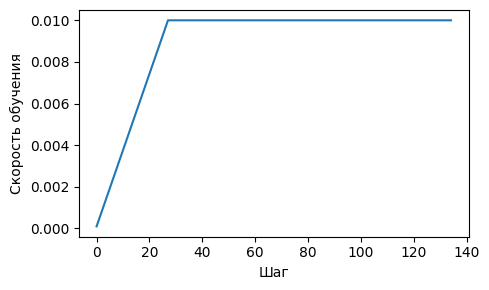

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.ylabel("Скорость обучения")
plt.xlabel("Шаг")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("1.pdf")
plt.show()

## D.2. Затухание по косинусу

- Ещё одним популярным методом обучения сложных глубоких нейронных сетей является косинусное затухание, которое также регулирует скорость обучения на протяжении эпох обучения
- При косинусном затухании скорость обучения следует косинусной кривой, уменьшаясь от своего начального значения до почти нуля по полукосинусному циклу
- Это постепенное снижение призвано замедлить темп обучения по мере того, как модель начинает улучшать свои веса; оно снижает риск проскочить мимо минимумов по мере прогресса обучения, что критически важно для стабилизации обучения на его поздних стадиях
- Косинусное затухание часто предпочитают линейному затуханию за более плавный переход в регулировке скорости обучения, но линейное затухание также используется на практике (например, [OLMo: Accelerating the Science of Language Models](https://arxiv.org/abs/2402.00838))

In [8]:
import math

min_lr = 0.1 * initial_lr
track_lrs = []

lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
    
        # Регулируем скорость обучения в зависимости от текущей фазы (разогрев или косинусное затухание)
        if global_step < warmup_steps:
            # Линейный разогрев
            lr = initial_lr + global_step * lr_increment  
        else:
            # Косинусное затухание после разогрева
            progress = ((global_step - warmup_steps) / 
                        (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                1 + math.cos(math.pi * progress))
        
        # Применяем вычисленную скорость обучения к оптимизатору
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])
    
        # Вычисляем потери и обновляем веса

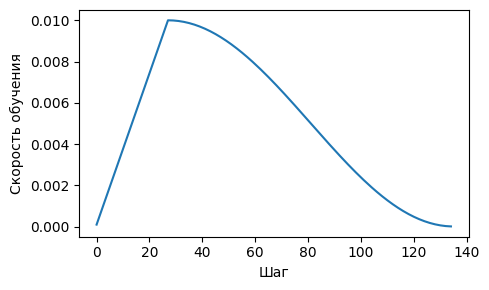

In [9]:
plt.figure(figsize=(5, 3))
plt.ylabel("Скорость обучения")
plt.xlabel("Шаг")
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("2.pdf")
plt.show()